# AQI Prediction — Training Pipeline

Trains and compares multiple forecasting models to predict AQI at **three horizons —
24h (Day 1), 48h (Day 2), and 72h (Day 3) ahead** — from a simple statistical baseline
through to a deep learning model, then explains feature importance with SHAP.

**Models compared (trained separately for each horizon):**
1. Naive persistence (baseline — "AQI at horizon h = AQI right now")
2. Ridge Regression (statistical)
3. Random Forest (classical ML)
4. Neural Network / MLP (deep learning)

**Requirements:** `pip install scikit-learn tensorflow shap joblib pandas numpy matplotlib seaborn`

**Note on data size:** with ~1 month of hourly data, the deep learning model has very
little to learn from and may not outperform Random Forest yet — that's expected and
worth calling out in your report rather than a bug to chase. Revisit once you've
backfilled more history.

In [1]:
import os
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
np.random.seed(42)


## 1. Load Feature Store Data

Same CSV your EDA notebook used. Adjust the path if needed.

In [2]:
DATA_PATH = "D:/AQI_Project/src/data/aqi_history.csv"  # <-- adjust if needed

df = pd.read_csv(DATA_PATH, parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print(f"Rows: {len(df)}")
print(f"Date range: {df['datetime'].min()}  ->  {df['datetime'].max()}")
df.head()


Rows: 2208
Date range: 2026-04-17 00:00:00  ->  2026-07-17 23:00:00


,temperature,humidity,pressure,datetime,pm10,pm2_5,co,no,no2,o3,so2,nh3,aqi,hour,day,month,day_of_week,week_of_year,aqi_change_rate
0,19.9,67,1011.6,2026-04-17 00:00:00,51.7,43.1,285.0,0.1,36.6,37.0,6.1,NaN,85,0,17,4,4,16,NaN
1,19.1,73,1012.3,2026-04-17 01:00:00,40.3,32.4,295.0,0.0,23.3,62.0,5.3,NaN,85,1,17,4,4,16,0.0
2,18.5,79,1012.4,2026-04-17 02:00:00,36.7,20.5,307.0,0.0,13.3,79.0,4.7,NaN,84,2,17,4,4,16,-1.0
3,17.3,86,1012.3,2026-04-17 03:00:00,33.8,17.9,303.0,0.0,10.0,80.0,4.2,NaN,83,3,17,4,4,16,-1.0
4,16.9,87,1012.0,2026-04-17 04:00:00,33.4,18.3,301.0,0.0,10.0,72.0,3.8,NaN,81,4,17,4,4,16,-2.0


## 2. Data Cleaning

`nh3` came back fully empty from the historical pollution API (confirmed in the EDA
notebook), so it's dropped here rather than silently feeding the model an all-NaN
column. `aqi_change_rate` has one NaN in its very first row (nothing to diff against) —
filled with 0 since there's no prior reading.

In [3]:
df = df.drop(columns=["nh3"], errors="ignore")
df["aqi_change_rate"] = df["aqi_change_rate"].fillna(0)

assert df.isnull().sum().sum() == 0, "Unexpected NaNs remain — investigate before training"
print("Clean. Shape:", df.shape)


Clean. Shape: (2208, 18)


## 3. Build the Forecasting Targets (24h / 48h / 72h ahead)

The project asks for **the next 3 days**, not a single 3-day-out number — so this
creates **three** target columns, one per horizon: *"what will AQI be 24 / 48 / 72
hours from this row's timestamp?"* Each horizon gets its own model later, so you get
a genuine tomorrow / day-after / day-after-that forecast.

In [4]:
HORIZONS = {24: "24h (Day 1)", 48: "48h (Day 2)", 72: "72h (Day 3)"}

for h in HORIZONS:
    df[f"aqi_target_{h}h"] = df["aqi"].shift(-h)

target_cols = [f"aqi_target_{h}h" for h in HORIZONS]
MAX_HORIZON = max(HORIZONS)

df_model = df.dropna(subset=target_cols).reset_index(drop=True)

print(f"Usable rows after creating {MAX_HORIZON}h-ahead targets: {len(df_model)}")
print(f"(Lost {len(df) - len(df_model)} rows at the end with no future target)")

df_model.head()


Usable rows after creating 72h-ahead targets: 2136
(Lost 72 rows at the end with no future target)


,temperature,humidity,pressure,datetime,pm10,pm2_5,co,no,no2,o3,...,aqi,hour,day,month,day_of_week,week_of_year,aqi_change_rate,aqi_target_24h,aqi_target_48h,aqi_target_72h
0,19.9,67,1011.6,2026-04-17 00:00:00,51.7,43.1,285.0,0.1,36.6,37.0,...,85,0,17,4,4,16,0.0,78.0,96.0,96.0
1,19.1,73,1012.3,2026-04-17 01:00:00,40.3,32.4,295.0,0.0,23.3,62.0,...,85,1,17,4,4,16,0.0,77.0,96.0,97.0
2,18.5,79,1012.4,2026-04-17 02:00:00,36.7,20.5,307.0,0.0,13.3,79.0,...,84,2,17,4,4,16,-1.0,77.0,97.0,98.0
3,17.3,86,1012.3,2026-04-17 03:00:00,33.8,17.9,303.0,0.0,10.0,80.0,...,83,3,17,4,4,16,-1.0,78.0,97.0,98.0
4,16.9,87,1012.0,2026-04-17 04:00:00,33.4,18.3,301.0,0.0,10.0,72.0,...,81,4,17,4,4,16,-2.0,80.0,98.0,97.0


## 4. Feature / Target Split + Chronological Train/Test Split

Time series data must be split **by time**, not shuffled randomly — otherwise the
model effectively "sees the future" during training, which would make the evaluation
numbers meaningless. `X` is shared across horizons; only `y` changes.

In [5]:
feature_cols = [
    "temperature", "humidity", "pressure",
    "co", "no", "no2", "o3", "so2", "pm2_5", "pm10",
    "hour", "day", "month", "day_of_week", "week_of_year",
    "aqi", "aqi_change_rate",
]

X = df_model[feature_cols]
y_by_horizon = {h: df_model[f"aqi_target_{h}h"] for h in HORIZONS}

split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]

y_train_by_horizon = {h: y.iloc[:split_idx] for h, y in y_by_horizon.items()}
y_test_by_horizon = {h: y.iloc[split_idx:] for h, y in y_by_horizon.items()}

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")
print(f"Train period: {df_model['datetime'].iloc[0]} -> {df_model['datetime'].iloc[split_idx-1]}")
print(f"Test period:  {df_model['datetime'].iloc[split_idx]} -> {df_model['datetime'].iloc[-1]}")


Train: 1708 rows | Test: 428 rows
Train period: 2026-04-17 00:00:00 -> 2026-06-27 03:00:00
Test period:  2026-06-27 04:00:00 -> 2026-07-14 23:00:00


## 5. Evaluation Helper

Every model gets scored the same way (RMSE, MAE, R²), now keyed by both **horizon**
and **model name**, so results stay directly comparable across the three forecasts.

In [6]:
results = defaultdict(dict)  # results[horizon_label][model_name] = {"RMSE":..., "MAE":..., "R2":...}

def evaluate(horizon_label, model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    results[horizon_label][model_name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    print(f"[{horizon_label:>12s}] {model_name:>20s}  RMSE={rmse:6.2f}   MAE={mae:6.2f}   R2={r2:6.3f}")
    return rmse, mae, r2


## 6. Baseline — Naive Persistence

The simplest possible forecast: assume AQI at horizon *h* equals AQI right now. Any
real model needs to beat this to be worth deploying, at every horizon.

In [7]:
y_pred_naive = {}

for h, label in HORIZONS.items():
    y_pred_naive[h] = X_test["aqi"].values  # "current AQI" as the forecast
    evaluate(label, "Naive Persistence", y_test_by_horizon[h], y_pred_naive[h])


[ 24h (Day 1)]    Naive Persistence  RMSE= 19.36   MAE= 15.80   R2= 0.384
[ 48h (Day 2)]    Naive Persistence  RMSE= 23.49   MAE= 18.25   R2= 0.047
[ 72h (Day 3)]    Naive Persistence  RMSE= 25.96   MAE= 21.90   R2=-0.265


## 7. Statistical Model — Ridge Regression

A regularized linear model — interpretable coefficients, fast to train, good sanity
check for how much signal is actually linear. One fit per horizon.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_models = {}
y_pred_ridge = {}

for h, label in HORIZONS.items():
    ridge = Ridge(alpha=1.0, random_state=42)
    ridge.fit(X_train_scaled, y_train_by_horizon[h])
    y_pred_ridge[h] = ridge.predict(X_test_scaled)
    ridge_models[h] = ridge
    evaluate(label, "Ridge Regression", y_test_by_horizon[h], y_pred_ridge[h])


[ 24h (Day 1)]     Ridge Regression  RMSE= 19.04   MAE= 15.57   R2= 0.404
[ 48h (Day 2)]     Ridge Regression  RMSE= 25.10   MAE= 21.10   R2=-0.088
[ 72h (Day 3)]     Ridge Regression  RMSE= 26.59   MAE= 22.96   R2=-0.328


## 8. Classical ML — Random Forest

Handles non-linear relationships and feature interactions without needing scaled
inputs — usually a strong tabular-data baseline. One fit per horizon.

In [9]:
rf_models = {}
y_pred_rf = {}

for h, label in HORIZONS.items():
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train_by_horizon[h])
    y_pred_rf[h] = rf.predict(X_test)
    rf_models[h] = rf
    evaluate(label, "Random Forest", y_test_by_horizon[h], y_pred_rf[h])


[ 24h (Day 1)]        Random Forest  RMSE= 20.64   MAE= 16.49   R2= 0.299
[ 48h (Day 2)]        Random Forest  RMSE= 24.31   MAE= 19.94   R2=-0.021
[ 72h (Day 3)]        Random Forest  RMSE= 30.72   MAE= 25.75   R2=-0.772


## 9. Deep Learning — Neural Network (Keras/TensorFlow)

A small feed-forward network (MLP), one per horizon. With only ~1 month of data this
won't have much to learn from yet — included to satisfy the "statistical to deep
learning" requirement and as a foundation to revisit once more history is backfilled.

In [10]:
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

nn_models = {}
nn_histories = {}
y_pred_nn = {}

for h, label in HORIZONS.items():
    nn_model = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])

    nn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")
    early_stop = keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)

    history = nn_model.fit(
        X_train_scaled, y_train_by_horizon[h],
        validation_split=0.15,
        epochs=200,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0,
    )

    y_pred_nn[h] = nn_model.predict(X_test_scaled, verbose=0).flatten()
    nn_models[h] = nn_model
    nn_histories[h] = history
    evaluate(label, "Neural Network", y_test_by_horizon[h], y_pred_nn[h])


[ 24h (Day 1)]       Neural Network  RMSE= 21.04   MAE= 16.59   R2= 0.272
[ 48h (Day 2)]       Neural Network  RMSE= 27.75   MAE= 23.06   R2=-0.330
[ 72h (Day 3)]       Neural Network  RMSE= 28.27   MAE= 24.28   R2=-0.501


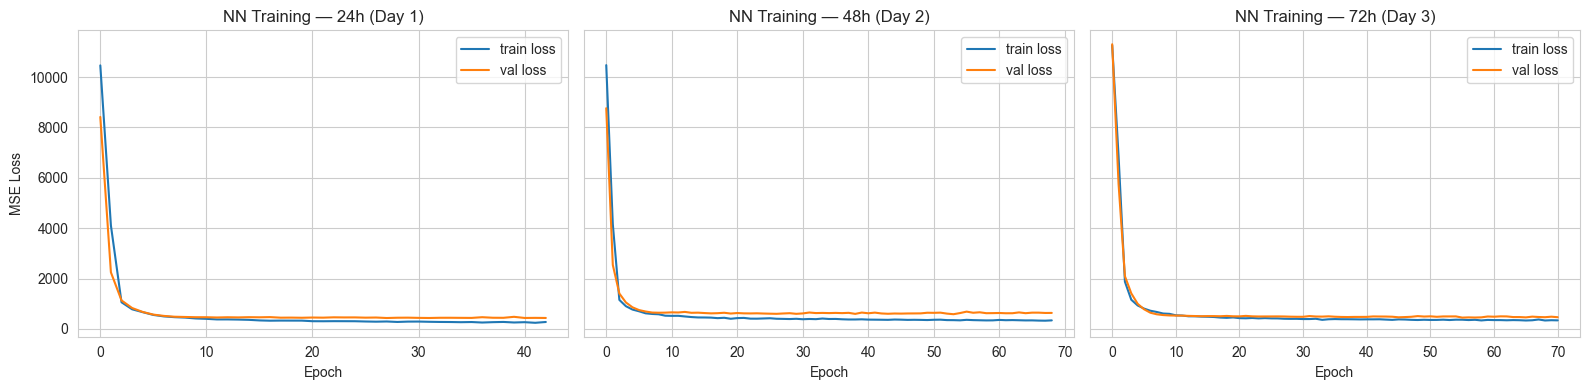

In [11]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(16, 4), sharey=True)

for ax, (h, label) in zip(axes, HORIZONS.items()):
    hist = nn_histories[h].history
    ax.plot(hist["loss"], label="train loss")
    ax.plot(hist["val_loss"], label="val loss")
    ax.set_title(f"NN Training — {label}")
    ax.set_xlabel("Epoch")
    ax.legend()

axes[0].set_ylabel("MSE Loss")
plt.tight_layout()
plt.show()


## 10. Model Comparison

Now broken out per horizon — the best model at 24h isn't guaranteed to be the best at
72h, so don't assume one algorithm wins everywhere.


=== 24h (Day 1) ===
                        RMSE        MAE        R2
Ridge Regression   19.043638  15.572838  0.403666
Naive Persistence  19.361116  15.801402  0.383617
Random Forest      20.642322  16.493976  0.299341
Neural Network     21.035354  16.586546  0.272406

=== 48h (Day 2) ===
                        RMSE        MAE        R2
Naive Persistence  23.489757  18.245327  0.047321
Random Forest      24.312947  19.936041 -0.020622
Ridge Regression   25.097621  21.099454 -0.087564
Neural Network     27.751693  23.055848 -0.329746

=== 72h (Day 3) ===
                        RMSE        MAE        R2
Naive Persistence  25.957055  21.899533 -0.265495
Ridge Regression   26.588480  22.960116 -0.327812
Neural Network     28.273133  24.276590 -0.501403
Random Forest      30.715653  25.750843 -0.772021


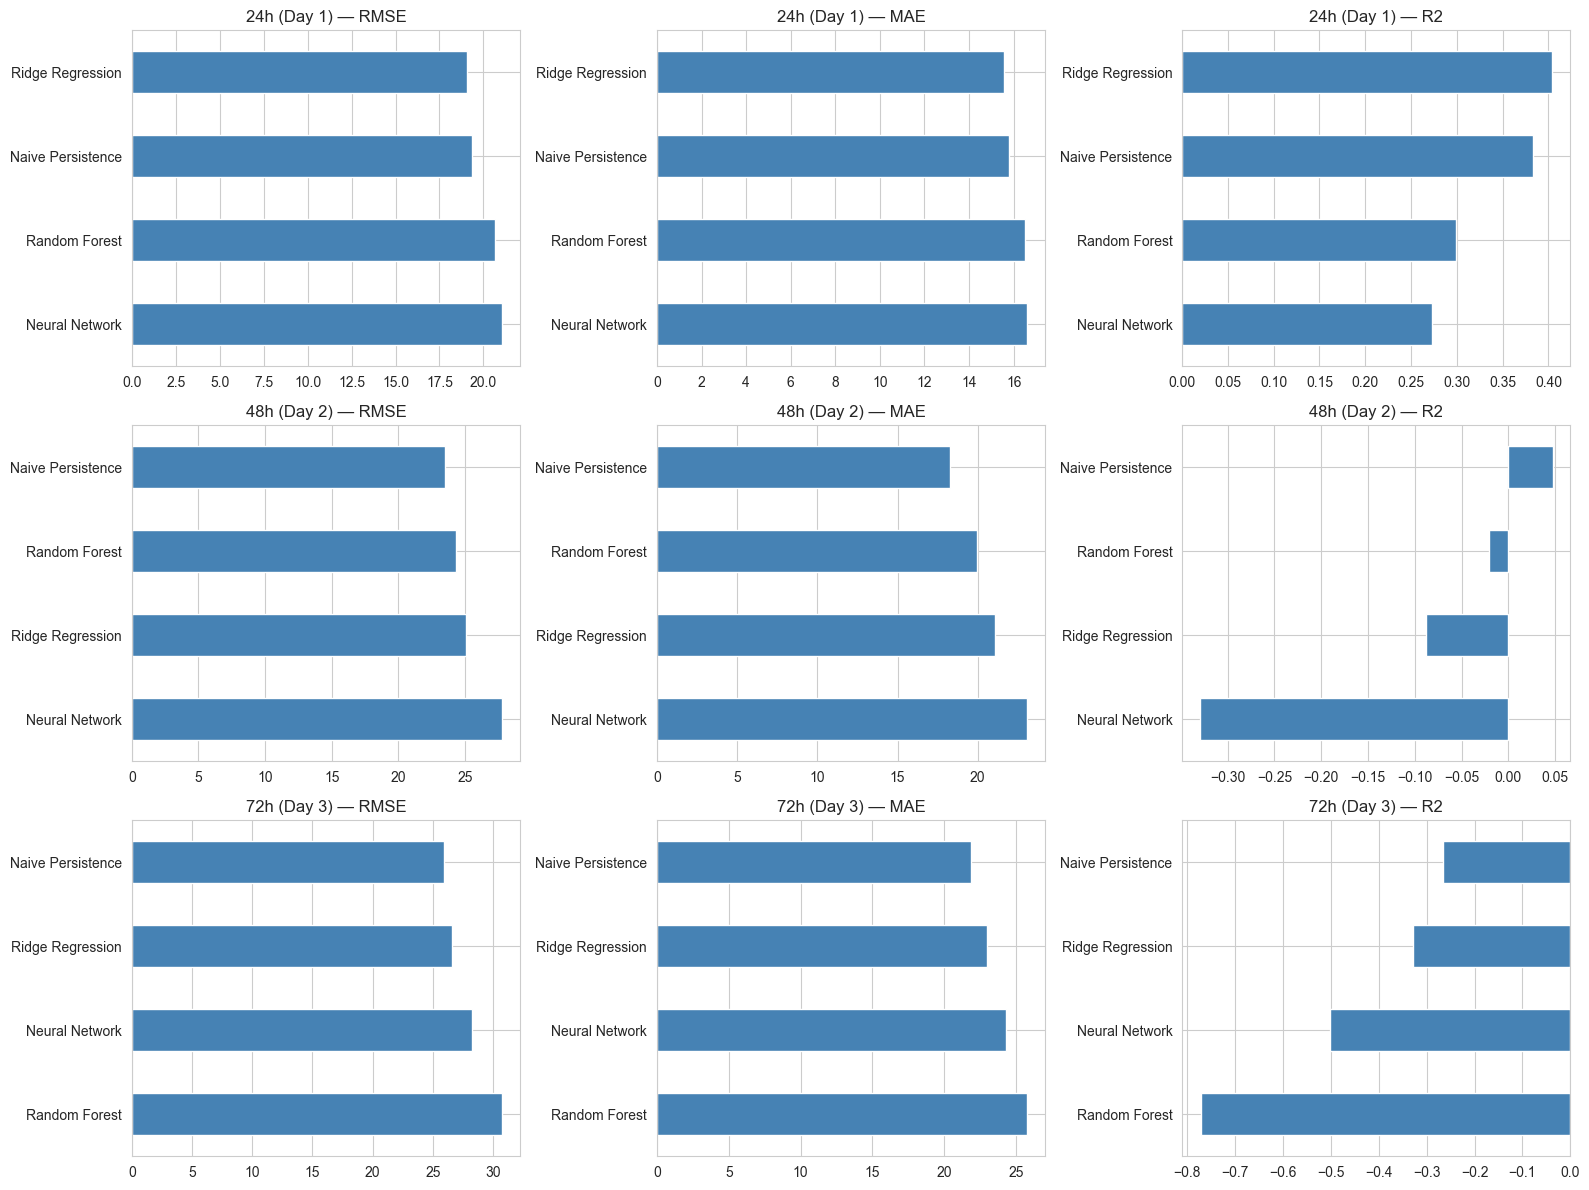


Best model for 24h (Day 1): Ridge Regression
Best model for 48h (Day 2): Naive Persistence
Best model for 72h (Day 3): Naive Persistence


In [12]:
for h, label in HORIZONS.items():
    print(f"\n=== {label} ===")
    print(pd.DataFrame(results[label]).T.sort_values("RMSE"))

fig, axes = plt.subplots(len(HORIZONS), 3, figsize=(16, 4 * len(HORIZONS)))

for row, (h, label) in enumerate(HORIZONS.items()):
    horizon_df = pd.DataFrame(results[label]).T.sort_values("RMSE")
    for col, metric in enumerate(["RMSE", "MAE", "R2"]):
        ax = axes[row, col]
        horizon_df[metric].plot(kind="barh", ax=ax, color="steelblue")
        ax.set_title(f"{label} — {metric}")
        ax.invert_yaxis()

plt.tight_layout()
plt.show()

print()
for h, label in HORIZONS.items():
    horizon_df = pd.DataFrame(results[label]).T
    print(f"Best model for {label}: {horizon_df['RMSE'].idxmin()}")


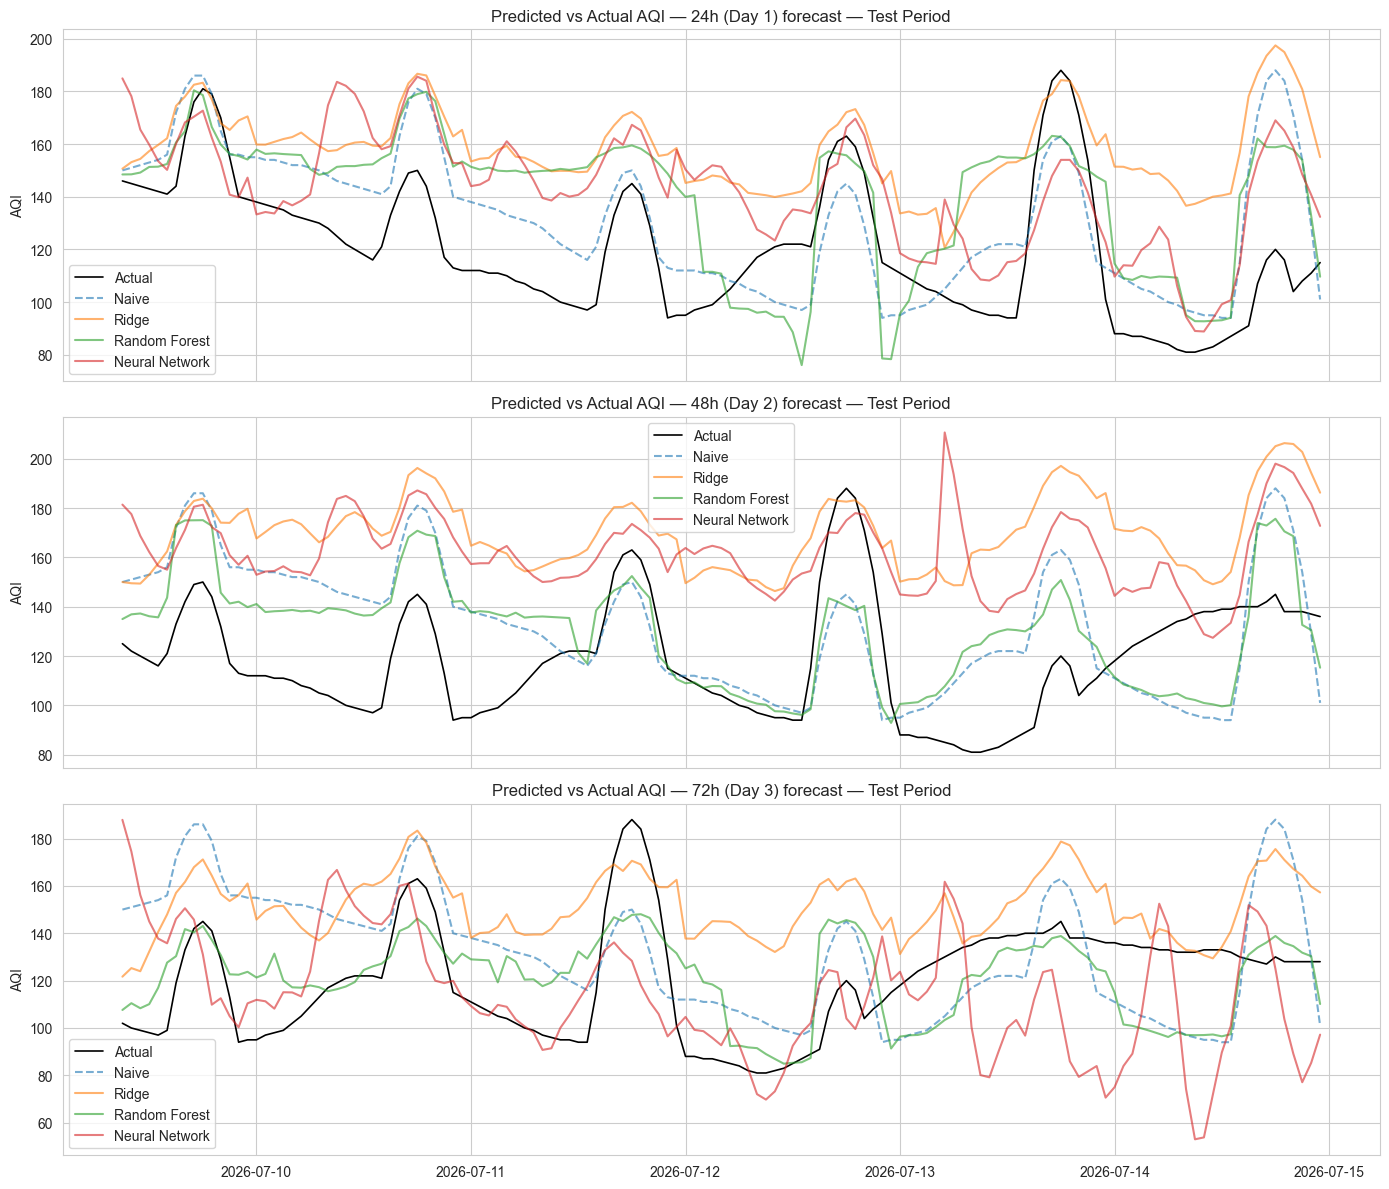

In [ ]:
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(14, 4 * len(HORIZONS)), sharex=True)
test_dates = df_model["datetime"].iloc[split_idx:]

for ax, (h, label) in zip(axes, HORIZONS.items()):
    ax.plot(test_dates, y_test_by_horizon[h].values, label="Actual", color="black", linewidth=1.2)
    ax.plot(test_dates, y_pred_naive[h], label="Naive", alpha=0.6, linestyle="--")
    ax.plot(test_dates, y_pred_ridge[h], label="Ridge", alpha=0.6)
    ax.plot(test_dates, y_pred_rf[h], label="Random Forest", alpha=0.6)
    ax.plot(test_dates, y_pred_nn[h], label="Neural Network", alpha=0.6)
    ax.set_title(f"Predicted vs Actual AQI — {label} forecast — Test Period")
    ax.set_ylabel("AQI")
    ax.legend()

plt.tight_layout()
plt.show()


## 11. Feature Importance with SHAP

Explains *which features* drive each Random Forest's predictions — required by the
project guidelines, and generally more informative than the model's built-in
`feature_importances_` since SHAP accounts for interactions and direction of effect.
Run once per horizon, since a different model is fit for each.

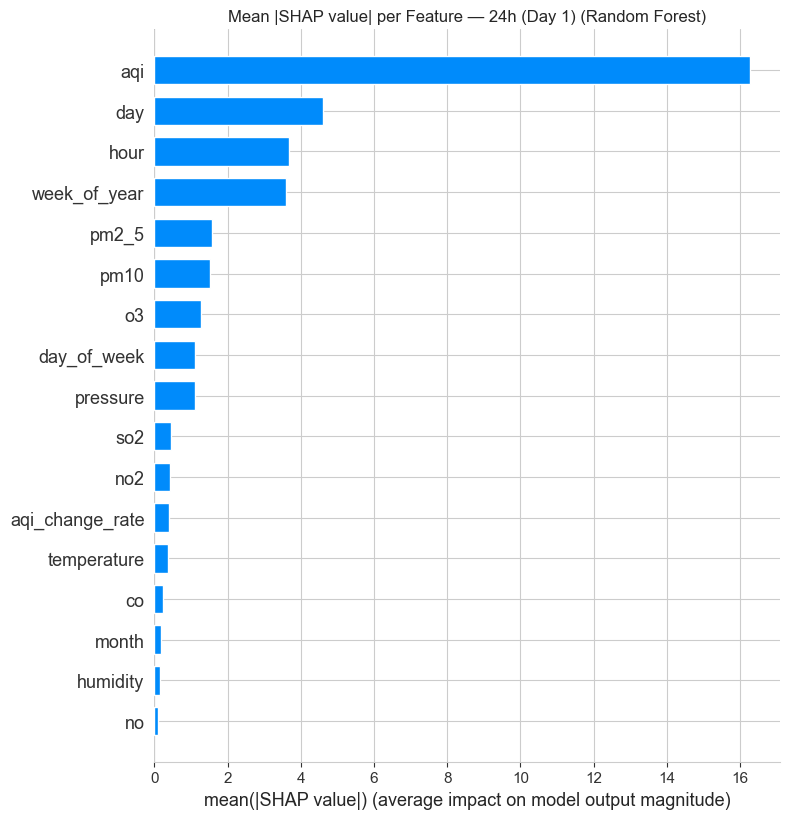

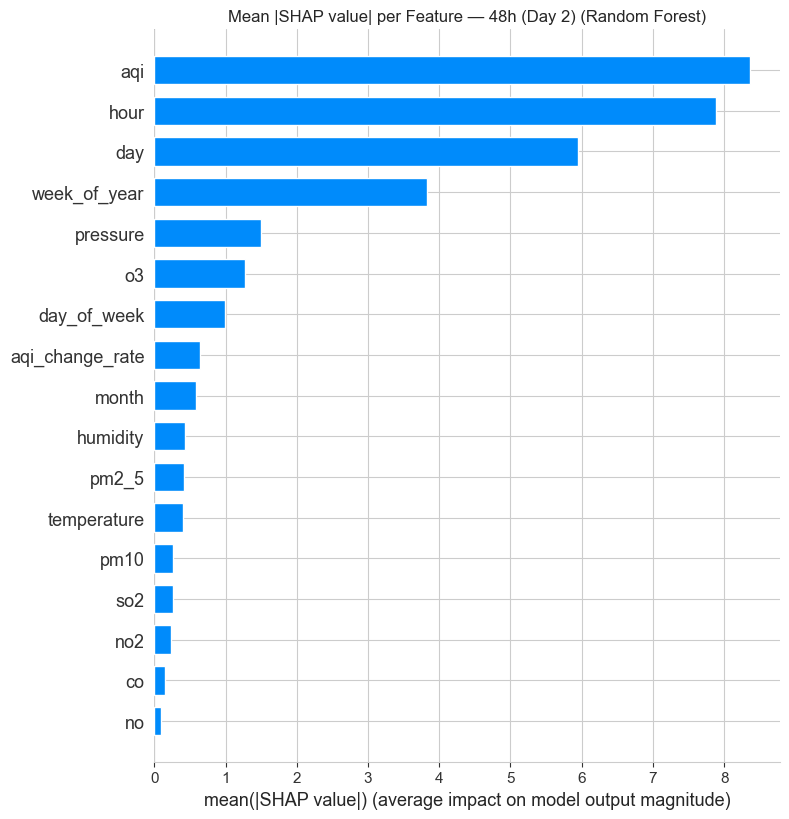

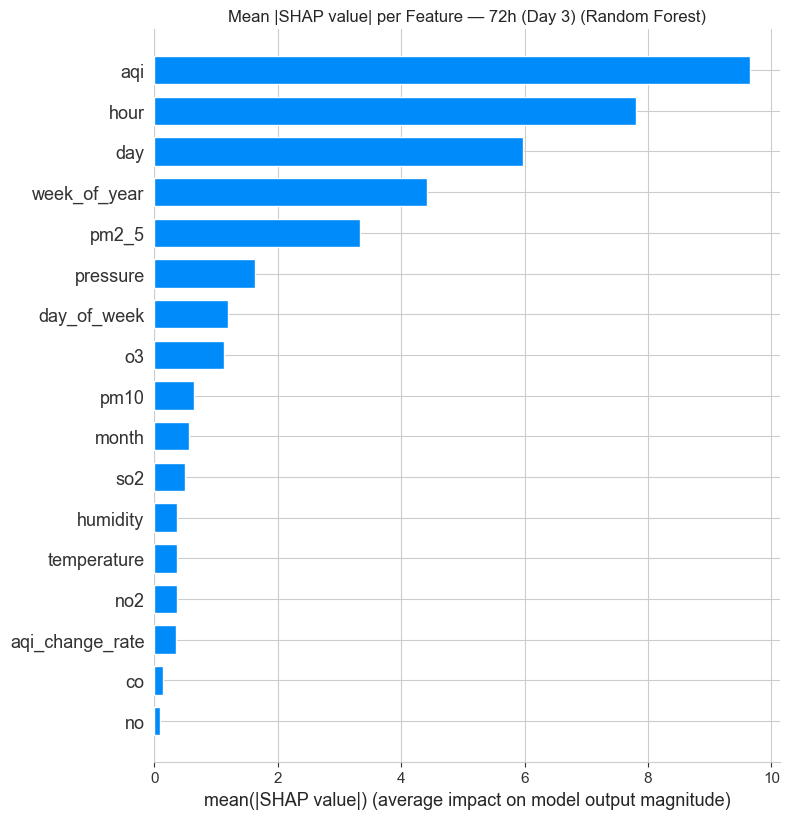

In [13]:
import shap

shap_values_by_horizon = {}

for h, label in HORIZONS.items():
    explainer = shap.TreeExplainer(rf_models[h])
    shap_values_by_horizon[h] = explainer.shap_values(X_test)

    shap.summary_plot(shap_values_by_horizon[h], X_test, plot_type="bar", show=False)
    plt.title(f"Mean |SHAP value| per Feature — {label} (Random Forest)")
    plt.tight_layout()
    plt.show()


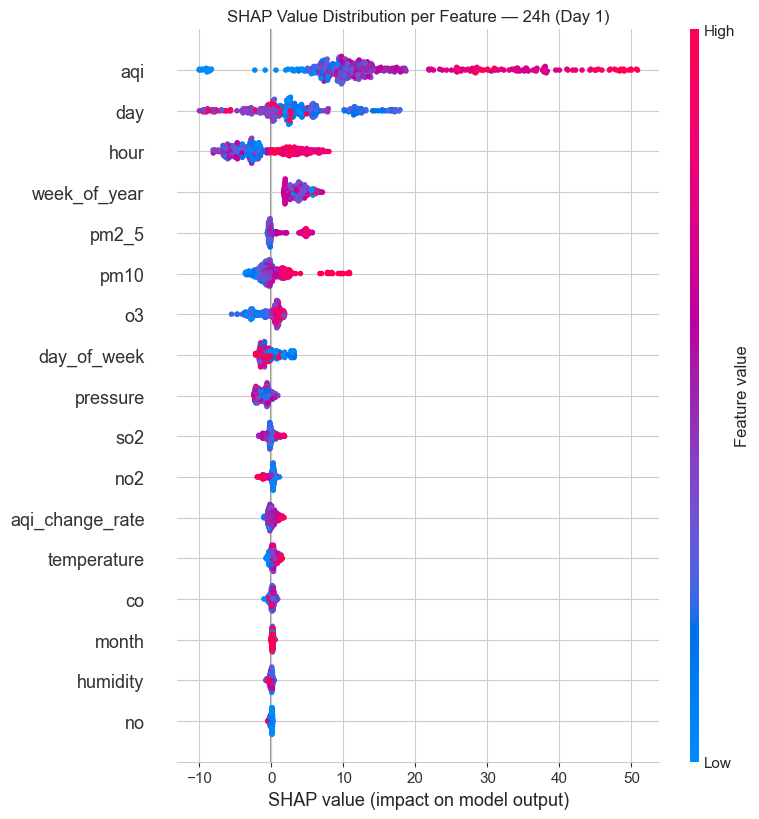

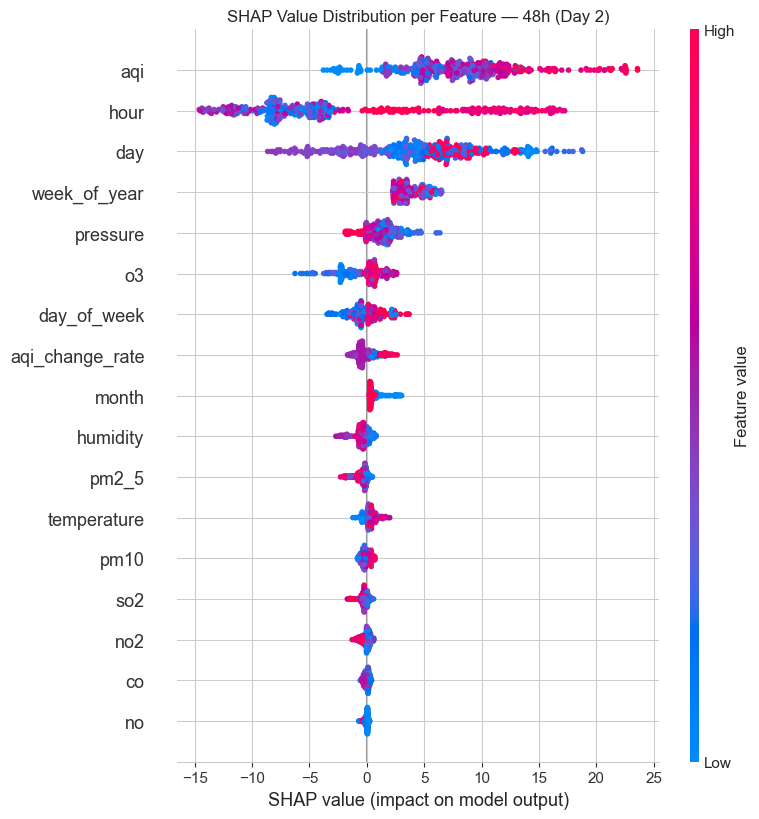

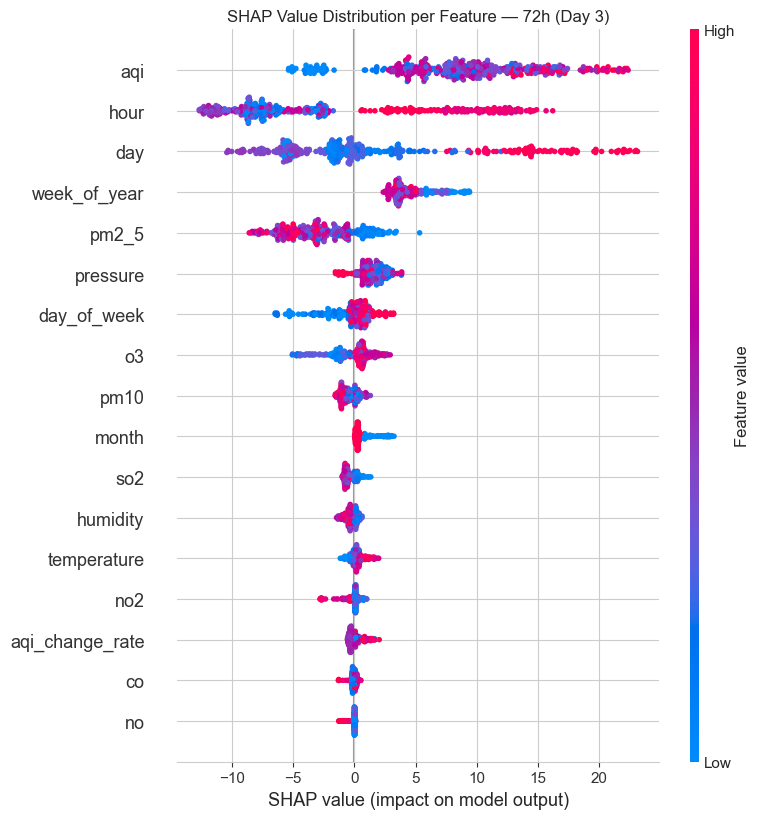

In [14]:
for h, label in HORIZONS.items():
    shap.summary_plot(shap_values_by_horizon[h], X_test, show=False)
    plt.title(f"SHAP Value Distribution per Feature — {label}")
    plt.tight_layout()
    plt.show()


**How to read this:** each dot is one test-set prediction. Position on the x-axis
shows how much that feature pushed the prediction up or down; color shows whether the
feature's own value was high (red) or low (blue) for that row. E.g. if `pressure`
shows red dots clustered on the negative side, low pressure is pushing predicted AQI
down for that model — cross-check this against the actual correlation sign from your
EDA notebook to sanity-check the model isn't learning something spurious. Compare
across horizons too: a feature that matters a lot at 24h but fades by 72h suggests its
influence is short-lived (e.g. current pollutant levels vs. slower-moving weather
patterns).

## 12. Hazardous AQI Alerting

A simple threshold check per the project guidelines ("Add alerts for hazardous AQI
levels") — using standard US AQI breakpoints. This is the same logic your web app's
dashboard would call on each new prediction, run per horizon.

In [17]:
def aqi_alert_level(aqi_value: float) -> str:
    if aqi_value <= 50:
        return "Good"
    elif aqi_value <= 100:
        return "Moderate"
    elif aqi_value <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi_value <= 200:
        return "Unhealthy"
    elif aqi_value <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

# alerts_by_horizon = {}

# for h, label in HORIZONS.items():
#     assert len(test_dates) == len(y_pred_rf[h]), (
#         f"{label}: test_dates has {len(test_dates)} rows but y_pred_rf[{h}] has "
#         f"{len(y_pred_rf[h])} — rerun the notebook top-to-bottom, state is stale."
#     )
#     alerts_by_horizon[h] = pd.DataFrame({
#         "datetime": test_dates.values,
#         "predicted_aqi": y_pred_rf[h],
#         "alert_level": [aqi_alert_level(v) for v in y_pred_rf[h]],
#     })
#     hazardous = alerts_by_horizon[h][
#         alerts_by_horizon[h]["alert_level"].isin(["Unhealthy", "Very Unhealthy", "Hazardous"])
#     ]
#     print(f"{label}: {len(hazardous)} of {len(alerts_by_horizon[h])} test predictions flagged unhealthy or worse")
# alerts_by_horizon[72].head()


## 13. Next 3 Days Forecast (from the latest available reading)

This is the part that answers "what will AQI be tomorrow, in 2 days, and in 3 days?" —
one prediction per horizon, generated from the single most recent row of features
(today's readings), using the Random Forest models. This is what a live dashboard
would call after each new hourly reading comes in.

In [16]:
latest_features = df[feature_cols].iloc[[-1]]  # most recent row, kept 2D for predict()
latest_time = df["datetime"].iloc[-1]

forecast_rows = []
for h, label in HORIZONS.items():
    pred = rf_models[h].predict(latest_features)[0]
    forecast_rows.append({
        "horizon": label,
        "target_time": latest_time + pd.Timedelta(hours=h),
        "predicted_aqi": round(pred, 1),
        "alert_level": aqi_alert_level(pred),
    })

next_3_days_forecast = pd.DataFrame(forecast_rows)
print(f"Forecast generated from latest reading at: {latest_time}")
next_3_days_forecast


Forecast generated from latest reading at: 2026-07-17 23:00:00


,horizon,target_time,predicted_aqi,alert_level
0,24h (Day 1),2026-07-18 23:00:00,113.1,Unhealthy for Sensitive Groups
1,48h (Day 2),2026-07-19 23:00:00,106.5,Unhealthy for Sensitive Groups
2,72h (Day 3),2026-07-20 23:00:00,111.3,Unhealthy for Sensitive Groups


## 14. Save the Best Models (Model Registry stand-in)

For now this saves locally with `joblib`/Keras — swap this for a Hopsworks/Vertex AI
model registry `push` call once you wire that up, per the project's "Training
pipeline" step 3. One Random Forest and one Neural Network per horizon; the scaler is
shared since `X` is identical across horizons.

In [ ]:
os.makedirs("models", exist_ok=True)

for h, label in HORIZONS.items():
    joblib.dump(rf_models[h], f"models/aqi_random_forest_{h}h.pkl")
    nn_models[h].save(f"models/aqi_neural_network_{h}h.keras")
    print(f"Saved: models/aqi_random_forest_{h}h.pkl")
    print(f"Saved: models/aqi_neural_network_{h}h.keras")

joblib.dump(scaler, "models/feature_scaler.pkl")  # shared across horizons — same X
print("Saved: models/feature_scaler.pkl")


Saved: models/aqi_random_forest_24h.pkl
Saved: models/aqi_neural_network_24h.keras
Saved: models/aqi_random_forest_48h.pkl
Saved: models/aqi_neural_network_48h.keras
Saved: models/aqi_random_forest_72h.pkl
Saved: models/aqi_neural_network_72h.keras
Saved: models/feature_scaler.pkl


## 15. Key Findings

_Fill in once you've run this against your real data:_

- Best-performing model at each horizon: 24h — ... | 48h — ... | 72h — ...
- Did any model beat the naive persistence baseline meaningfully, and at which
  horizons? (Naive tends to be hardest to beat at 24h and easiest to beat at 72h.)
- Top SHAP features per horizon, and do they match the correlations from the EDA
  notebook? Do the top features shift between 24h and 72h?
- Is the neural network underfitting due to limited data? Worth revisiting after a
  longer backfill (3-6+ months)?
- Any features worth dropping (low SHAP importance, high collinearity)?
- Current `next_3_days_forecast` snapshot: ...